In [1]:
import pandas as pd

In [15]:
nlg = pd.read_csv('../Data/recipes/RecipeNLG.csv')

nlg.head()

,Unnamed: 0,title,ingredients,directions,link,source,NER
0,0,No-Bake Nut Cookies,"[""1 c. firmly packed brown sugar"", ""1/2 c. eva...","[""In a heavy 2-quart saucepan, mix brown sugar...",www.cookbooks.com/Recipe-Details.aspx?id=44874,Gathered,"[""brown sugar"", ""milk"", ""vanilla"", ""nuts"", ""bu..."
1,1,Jewell Ball'S Chicken,"[""1 small jar chipped beef, cut up"", ""4 boned ...","[""Place chipped beef on bottom of baking dish....",www.cookbooks.com/Recipe-Details.aspx?id=699419,Gathered,"[""beef"", ""chicken breasts"", ""cream of mushroom..."
2,2,Creamy Corn,"[""2 (16 oz.) pkg. frozen corn"", ""1 (8 oz.) pkg...","[""In a slow cooker, combine all ingredients. C...",www.cookbooks.com/Recipe-Details.aspx?id=10570,Gathered,"[""frozen corn"", ""cream cheese"", ""butter"", ""gar..."
3,3,Chicken Funny,"[""1 large whole chicken"", ""2 (10 1/2 oz.) cans...","[""Boil and debone chicken."", ""Put bite size pi...",www.cookbooks.com/Recipe-Details.aspx?id=897570,Gathered,"[""chicken"", ""chicken gravy"", ""cream of mushroo..."
4,4,Reeses Cups(Candy),"[""1 c. peanut butter"", ""3/4 c. graham cracker ...","[""Combine first four ingredients and press in ...",www.cookbooks.com/Recipe-Details.aspx?id=659239,Gathered,"[""peanut butter"", ""graham cracker crumbs"", ""bu..."


2231142

In [7]:
def extract_domain_from_url(url):
    return url.split('/')[0]

nlg['domain'] = nlg['link'].apply(extract_domain_from_url)


In [9]:
nyt = nlg[nlg['domain'] == 'cooking.nytimes.com']

nyt.head()

,Unnamed: 0,title,ingredients,directions,link,source,NER,domain
1643132,1643132,Chirashi (Scattered) Sushi,"[""6 cups prepared sushi rice (see recipe)"", ""2...","[""Place a cup of rice, cooled to just above ro...",cooking.nytimes.com/recipes/10753,Recipes1M,"[""rice"", ""avocados"", ""Salt"", ""cucumber"", ""nori...",cooking.nytimes.com
1643171,1643171,Spicy Korean Temple Noodles,"[""2 tablespoons gochujang (Korean chile paste)...","[""In a large bowl, mix together the gochujang,...",cooking.nytimes.com/recipes/1017290,Recipes1M,"[""gochujang"", ""Asian persimmon"", ""sugar"", ""bla...",cooking.nytimes.com
1643245,1643245,Broiled Veal Chops With Anchovy Butter,"[""3 tablespoons olive oil"", ""4 loin veal chops...","[""Preheat a charcoal or gas grill or preheat b...",cooking.nytimes.com/recipes/4338,Recipes1M,"[""olive oil"", ""veal chops"", ""ground cumin"", ""r...",cooking.nytimes.com
1643250,1643250,Josey Packards Autumnal Old-Fashioned,"[""1/2 teaspoon cinnamon simple syrup"", ""2 1/4 ...","[""Build ingredients in old-fashioned glass, ad...",cooking.nytimes.com/recipes/1015395,Recipes1M,"[""cinnamon simple syrup"", ""bonded applejack"", ...",cooking.nytimes.com
1643490,1643490,Deviled kidneys,"[""4 lamb kidneys, about 1/2 pound"", ""1 egg, li...","[""Preheat oven to 500 degrees."", ""Cut the kidn...",cooking.nytimes.com/recipes/2561,Recipes1M,"[""lamb kidneys"", ""egg"", ""English mustard"", ""Wo...",cooking.nytimes.com


In [17]:
food_nutrient = pd.read_csv('../Data/All_Food_Data_April_2026/food.csv')
food_nutrient.index.size/1000000

/var/folders/qq/pmrcg6p90876k5_k2lxpk37w0000gn/T/ipykernel_56146/2954410724.py:1: DtypeWarning: Columns (0: food_category_id) have mixed types. Specify dtype option on import or set low_memory=False.
  food_nutrient = pd.read_csv('../Data/All_Food_Data_April_2026/food.csv')


2.101279

In [18]:
branded_foods = pd.read_csv('../Data/All_Food_Data_April_2026/branded_food.csv')
branded_foods.index.size/1000000


/var/folders/qq/pmrcg6p90876k5_k2lxpk37w0000gn/T/ipykernel_56146/1430501214.py:1: DtypeWarning: Columns (0: brand_name, 1: subbrand_name, 2: gtin_upc, 3: not_a_significant_source_of, 4: package_weight, 5: discontinued_date, 6: preparation_state_code, 7: trade_channel, 8: short_description) have mixed types. Specify dtype option on import or set low_memory=False.
  branded_foods = pd.read_csv('../Data/All_Food_Data_April_2026/branded_food.csv')


1.99995

In [2]:
import json

records = []
with open("../Data/recipes/open_recipes.json", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

open_df = pd.DataFrame(records)
open_df.head()

,_id,name,ingredients,url,image,ts,cookTime,source,recipeYield,datePublished,prepTime,description,totalTime,creator,recipeCategory,dateModified,recipeInstructions
0,{'$oid': '5160756b96cc62079cc2db15'},Drop Biscuits and Sausage Gravy,Biscuits\n3 cups All-purpose Flour\n2 Tablespo...,http://thepioneerwoman.com/cooking/2013/03/dro...,http://static.thepioneerwoman.com/cooking/file...,{'$date': 1365276011104},PT30M,thepioneerwoman,12,2013-03-11,PT10M,"Late Saturday afternoon, after Marlboro Man ha...",NaN,NaN,NaN,NaN,NaN
1,{'$oid': '5160756d96cc62079cc2db16'},Hot Roast Beef Sandwiches,12 whole Dinner Rolls Or Small Sandwich Buns (...,http://thepioneerwoman.com/cooking/2013/03/hot...,http://static.thepioneerwoman.com/cooking/file...,{'$date': 1365276013902},PT20M,thepioneerwoman,12,2013-03-13,PT20M,"When I was growing up, I participated in my Ep...",NaN,NaN,NaN,NaN,NaN
2,{'$oid': '5160756f96cc6207a37ff777'},Morrocan Carrot and Chickpea Salad,Dressing:\n1 tablespoon cumin seeds\n1/3 cup /...,http://www.101cookbooks.com/archives/moroccan-...,http://www.101cookbooks.com/mt-static/images/f...,{'$date': 1365276015332},NaN,101cookbooks,NaN,2013-01-07,PT15M,A beauty of a carrot salad - tricked out with ...,NaN,NaN,NaN,NaN,NaN
3,{'$oid': '5160757096cc62079cc2db17'},Mixed Berry Shortcake,Biscuits\n3 cups All-purpose Flour\n2 Tablespo...,http://thepioneerwoman.com/cooking/2013/03/mix...,http://static.thepioneerwoman.com/cooking/file...,{'$date': 1365276016700},PT15M,thepioneerwoman,8,2013-03-18,PT15M,It's Monday! It's a brand new week! The birds ...,NaN,NaN,NaN,NaN,NaN
4,{'$oid': '5160757496cc6207a37ff778'},Pomegranate Yogurt Bowl,For each bowl: \na big dollop of Greek yogurt\...,http://www.101cookbooks.com/archives/pomegrana...,http://www.101cookbooks.com/mt-static/images/f...,{'$date': 1365276020318},NaN,101cookbooks,Serves 1.,2013-01-20,PT5M,A simple breakfast bowl made with Greek yogurt...,NaN,NaN,NaN,NaN,NaN


In [3]:
def count_ingredients(ingredients) -> int:
    """Split ingredients on newline and return the number of lines."""
    if ingredients is None or (isinstance(ingredients, float) and pd.isna(ingredients)):
        return 0
    return len(str(ingredients).split("\n"))


open_df["ingredient_count"] = open_df["ingredients"].apply(count_ingredients)
open_df[["name", "ingredients", "ingredient_count"]].head()

,name,ingredients,ingredient_count
0,Drop Biscuits and Sausage Gravy,Biscuits\n3 cups All-purpose Flour\n2 Tablespo...,12
1,Hot Roast Beef Sandwiches,12 whole Dinner Rolls Or Small Sandwich Buns (...,10
2,Morrocan Carrot and Chickpea Salad,Dressing:\n1 tablespoon cumin seeds\n1/3 cup /...,12
3,Mixed Berry Shortcake,Biscuits\n3 cups All-purpose Flour\n2 Tablespo...,17
4,Pomegranate Yogurt Bowl,For each bowl: \na big dollop of Greek yogurt\...,7


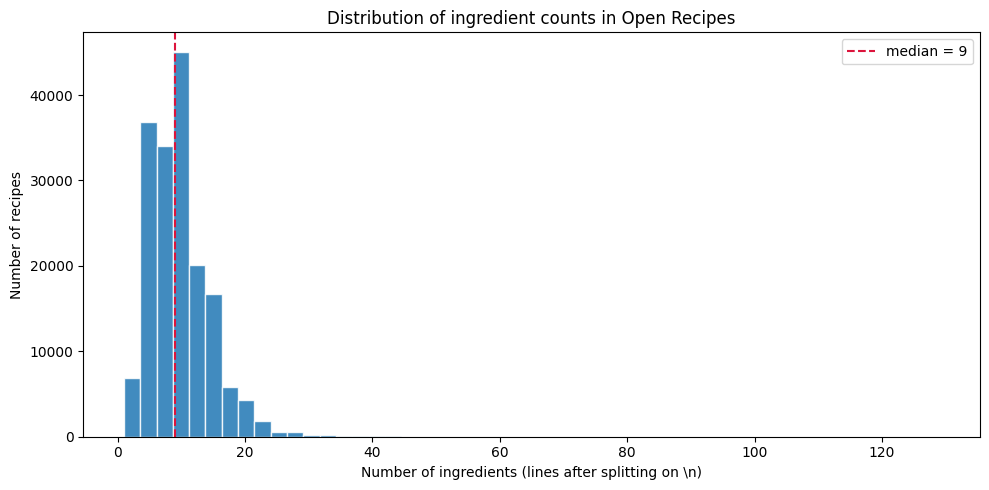

Recipes: 173,278
Mean ingredients: 9.8
Median ingredients: 9
Max ingredients: 129


In [4]:
import os

# Cursor/Jupyter sets MPLBACKEND to matplotlib_inline; ensure the package exists.
if os.environ.get("MPLBACKEND", "").startswith("module://matplotlib_inline"):
    try:
        import matplotlib_inline  # noqa: F401
    except ImportError:
        os.environ.pop("MPLBACKEND", None)

import matplotlib.pyplot as plt

counts = open_df["ingredient_count"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(counts, bins=50, edgecolor="white", alpha=0.85)
ax.set_xlabel("Number of ingredients (lines after splitting on \\n)")
ax.set_ylabel("Number of recipes")
ax.set_title("Distribution of ingredient counts in Open Recipes")
ax.axvline(counts.median(), color="crimson", linestyle="--", label=f"median = {counts.median():.0f}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Recipes: {len(open_df):,}")
print(f"Mean ingredients: {counts.mean():.1f}")
print(f"Median ingredients: {counts.median():.0f}")
print(f"Max ingredients: {counts.max()}")